In [1]:
import numpy as np
import matplotlib.pyplot as plt
import flpoAgent
import importlib
import random
from scipy.spatial.distance import cdist
import createEnv
from scipy.optimize import Bounds, LinearConstraint, minimize
import supporting_functions
from matplotlib.cm import get_cmap

n_waypoints: 3 
n_agents: 2 
CAT:
[3. 3. 3.]
---------
wp_locations:
[[-1.03751147e+01  7.20149090e+00]
 [ 9.92899450e+02  1.01218180e+00]
 [-1.45627511e+01  1.01256241e+03]] 
mask:
[[0 1 1]
 [1 0 0]
 [1 0 0]] 
dist_mat:
[[1.00000000e+08 1.00329366e+03 1.00536964e+03]
 [1.00329366e+03 1.00000000e+08 1.00000000e+08]
 [1.00536964e+03 1.00000000e+08 1.00000000e+08]] 
wp_weights:
[0.33333333 0.33333333 0.33333333]
---------
agent_weights:
[0.5 0.5] 
sd_mat:
[[2 1]
 [1 2]] 
eta_arr: 
processing_time:
[[0. 0. 0.]
 [0. 0. 0.]] 
speed_lim_mat:
[[5.38401999e-01 7.37812051e+01]
 [2.44292129e-02 7.35107228e+01]] 
sched_mat:
[[ 3.34214276 95.69493363  0.        ]
 [28.3828353   0.         94.42251361]]


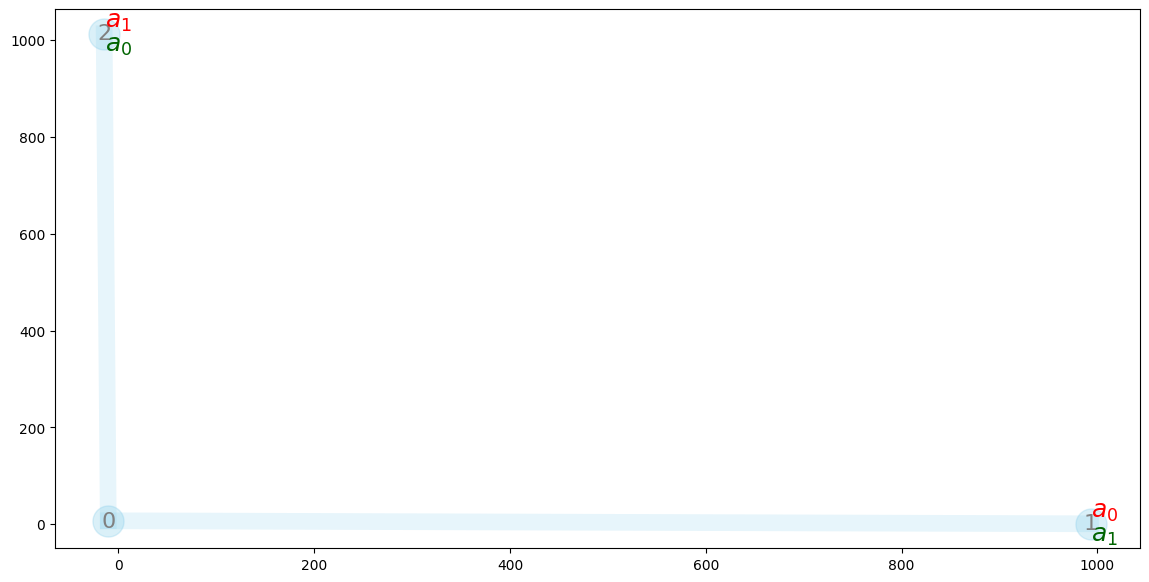

In [2]:
importlib.reload(flpoAgent)
importlib.reload(createEnv)
importlib.reload(supporting_functions)

# generate waypoints and the adjacency matrix
n_waypoints = 3
n_agents = 2
tolArray = np.random.uniform(3.0, 3.0, n_waypoints)

# Grid network parameters
grid_params = {
    'type':'grid',
    'n_points':n_waypoints,
    'grid_size':1000,
    'noise_factor':15
}

# Ring network parameters
ring_params = {
    'type':'ring',
    'num_rings':3,
    'points_per_ring':int(n_waypoints/3),
    'center_distance':1000,
    'deformation_level':50.0,
    'extra_connections':0.00,
    'missing_connections':0.05
}

# create a mars environment
mars = createEnv.MARS(
    n_waypoints, 
    n_agents, 
    tolArray, 
    grid_params, 
    seed=12, 
    offset_energy=1,
    printFlag=True)

# compute conflict cost
beta0=1e-8
gamma_t = 5
gamma_c = 7.5
coeff_t = 50
coeff_c = 5.0

# mars visualization
cmap = get_cmap('tab20')
agent_colors = {a: cmap(i / mars.n_agents) for i, a in enumerate(range(mars.n_agents))}
createEnv.plotNetwork(mars=mars, figuresize=(14,7), routes=[], agent_colors=agent_colors, showEdgeLength=False)

# agent visualization
# show_graph=0
# if show_graph:
#     for i,v in enumerate(mars.agents):
#         v.showGraph(mars.wp_locations, mars.dist_mat, mars.mask, mars.sched_mat[i,:], figuresize=(10,5), showEdgeTimeLim=True)



In [3]:
# agent_0 = mars.agents[0]
# sched0_init = mars.sched_mat[0,:]
# lb0 = np.zeros(sched0_init.shape)
# ub0 = 100 * np.ones(lb0.shape)
# bounds = Bounds(lb0, ub0)

In [4]:
# beta_min = 1e-5
# beta_max = 1e3
# beta_grow = 3
# beta = beta_min
# beta_arr = []
# while beta <= beta_max:
#     beta_arr.append(beta)
#     beta = beta * beta_grow

In [5]:
# for i, b in enumerate(beta_arr):
#     res = minimize(
#         agent_0.getFreeEnergy_s_v1,
#         sched0_init,
#         args = (mars.dist_mat, b),
#         method='slsqp',
#         options={'disp':0},
#         bounds=bounds
#     )
#     sched0_init = res.x

#     print(f'beta:{b:.4e}\tfreeEnergy:{res.fun:.4f}')



In [6]:
# Pb = agent_0.getPathAssociations_v1(sched0_init, mars.dist_mat, beta=1e8)
# agent_0.calc_route_and_schedule(sched0_init, mars.dist_mat, Pb)
# r = agent_0.route
# s = agent_0.fin_sched
# print(f'agent {agent_0}\n route: {r} \t schedule : {np.round(s,2)}')

### Test the optimization for all the agents together

In [7]:
# # annealing
# sched_vec0 = mars.sched_mat.flatten()

# lb = np.ones(shape=sched_vec0.shape)*mars.t_start_min
# ub = np.ones(shape=sched_vec0.shape)*100.0
# print(f'agent start nodes {mars.agents[0].s}')
# print(f'init schedule vec {sched_vec0}')
# print(f'ub {ub}')
# print(f'lb {lb}')

# sched_bounds = [lb,ub]
# beta_lims = [1e-6,1]
# beta_grow = 1.5
# # opts = {'gtol':1e-4, 'verbose':0, 'maxiter':200}
# opts = {'disp':0}
# C_arr, sched_vec, rt_arr, reach_mat_beta_data, filter_wp_beta_data, beta_arr, gamma_arr, conflict_C_arr, Pb_a = mars.annealing_v1(beta_lims=beta_lims,
#                                             beta_grow=beta_grow,
#                                             sched_vec0=sched_vec0,
#                                             init_sched_bounds=sched_bounds,
#                                             optimize_opt=opts,
#                                             allowPrintAnneal=True,
#                                             allowPrintOptimize=False)

# # C_arr, sched_vec, rt_arr, reach_mat_beta_data, filter_wp_beta_data, beta_arr, gamma_arr, conflict_C_arr, Pb_a = mars.annealing(beta_lims=beta_lims,
# #                                             beta_grow=beta_grow,
# #                                             sched_vec0=sched_vec0,
# #                                             init_sched_bounds=sched_bounds,
# #                                             optimize_opt=opts,
# #                                             allowPrintAnneal=True,
# #                                             allowPrintOptimize=False)



In [8]:
# importlib.reload(createEnv)
# importlib.reload(flpoAgent)
# print('\nOptimization Results')
# print(f'initial schedule:{sched_vec0}')
# print(f'final schedule:\n{mars.sched_mat}')
# print(f'processing time:\n{mars.process_T}')
# print(f'cost:{C_arr[-1]}')

# agent_routes, agent_schedules = createEnv.calc_agent_routes_and_schedules(mars, Pb_a, printRoutes=True)
# createEnv.plotNetwork(mars=mars, figuresize=(12,8), routes=agent_routes, agent_colors=agent_colors, showEdgeLength=False, plotPaths=True)
# # createEnv.plot_vehicle_routes(agent_routes, agent_schedules, mars.process_T, agent_colors)
# # createEnv.plot_waypoint_schedules(filter_wp_beta_data[-1], mars.sched_mat)
# createEnv.plot_waypoint_agent_schedules(
#     agent_routes, agent_schedules, mars.sched_mat, 
#     filter_wp_beta_data[-1], mars.process_T, agent_colors,
#     figuresize=(12,12))
# plt.figure(figsize=(8,4))
# plt.plot(np.log(beta_arr)/np.log(10), conflict_C_arr.sum(axis=1), marker='o', linewidth=2, color='red')
# plt.xlabel(rf'$\log\beta$', fontsize=14)
# plt.ylabel(rf'Cost', fontsize=14)
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.grid()
# plt.show()
# # agent visualization
# show_graph=0
# if show_graph:
#     for i,v in enumerate(mars.agents):
#         v.showGraph(mars.wp_locations, mars.dist_mat, mars.mask, mars.sched_mat[i,:], figuresize=(10,5), showEdgeTimeLim=True)



### Write a code to solve MARS using CBF-CLF based appraoch

In [9]:
beta_min = 1e-5
beta_max = 1
beta_grow = 1.5
beta = beta_min
beta_arr = []
while beta <= beta_max:
    beta_arr.append(beta)
    beta = beta * beta_grow


T0 = np.ones((mars.n_agents, mars.n_waypoints))
for i in range(mars.n_agents):
    if i > 0:
        T0[i] = T0[i-1] + mars.tolArray + np.random.uniform(0,5, mars.tolArray.shape)


optimizer = {
    'name':'cbf_clf',
    'dt_init':0.01,
    'dt_min':1e-6,
    'dt_max':0.1,
    'Tf':20,
    'gamma':1,
    'alpha':2,
    'p':1,
    'stop_tol':0.001,
    'stop_tol_weight':np.array([1, 1, 1]),
    'verbose':0
}



In [10]:
active_waypoints = [] #range(mars.n_waypoints)
T, F, Pb_a = mars.anneal(beta_arr, T0, active_waypoints=active_waypoints, optimizer=optimizer, annealPrint=True)


beta: 1.0000e-05	cost: 3313.777	dot_cost: -20.974	tolb: 9.880e-04	delta_b: 3292.804	n_active_waypoints:0	tol_mag:0.00

beta: 1.5000e-05	cost: 3304.281	dot_cost: -10.925	tolb: 7.656e-04	delta_b: 3293.356	n_active_waypoints:0	tol_mag:0.00

beta: 2.2500e-05	cost: 3297.165	dot_cost: -24.198	tolb: 9.929e-04	delta_b: 3272.967	n_active_waypoints:0	tol_mag:0.00

beta: 3.3750e-05	cost: 3282.523	dot_cost: -28.080	tolb: 9.932e-04	delta_b: 3254.443	n_active_waypoints:0	tol_mag:0.00

beta: 5.0625e-05	cost: 3256.796	dot_cost: -19.554	tolb: 9.696e-04	delta_b: 3237.242	n_active_waypoints:0	tol_mag:0.00

beta: 7.5938e-05	cost: 3222.626	dot_cost: -25.361	tolb: 9.448e-04	delta_b: 3197.265	n_active_waypoints:0	tol_mag:0.00

beta: 1.1391e-04	cost: 3167.386	dot_cost: -19.651	tolb: 8.733e-04	delta_b: 3147.736	n_active_waypoints:0	tol_mag:0.00

beta: 1.7086e-04	cost: 3085.813	dot_cost: -18.567	tolb: 7.871e-04	delta_b: 3067.246	n_active_waypoints:0	tol_mag:0.00

beta: 2.5629e-04	cost: 2962.488	dot_cost: -14.0

In [11]:
mars.sched_mat = T
agent_routes, agent_schedules = createEnv.calc_agent_routes_and_schedules(mars, Pb_a, printRoutes=True)


route v0: [2, 0, 1], schedule: [ 0.68 27.73 54.74]
route v1: [1, 0, 2], schedule: [ 0.64 27.93 55.28]


In [13]:
beta_arr = [beta_max]
active_waypoints = range(mars.n_waypoints)
optimizer['verbose'] = 2
optimizer['alpha'] = 10
print(mars.tolArray)
T1, F, Pb_a = mars.anneal(beta_arr, T, active_waypoints=active_waypoints, optimizer=optimizer, annealPrint=True)

[2.5 2.5 2.5]
[[  -6.20940809 2919.85602602 2975.78844179]] [[  62.09408091 -586.70731949 -461.07842544]]
	t:0.000e+00	Fdot:-9.0284	F:1477.7564	dt:1.0000e-02	delta:1468.7280	tol:4.926e+02
[[  -3.21381001 2913.99189381 2971.17943982]] [[ 3.21381001e+01 -2.91399189e+04  6.40960860e+04]]
	t:1.000e-02	Fdot:-890.6462	F:1478.9341	dt:7.7243e-04	delta:588.2879	tol:7.715e-01
[[  -3.18893485 2891.52673169 3020.89496733]] [[ 3.18893485e+01 -2.89152673e+04  4.52380197e+04]]
	t:1.077e-02	Fdot:-351.8632	F:1478.4929	dt:4.4604e-04	delta:1126.6298	tol:2.596e-01
[[  -3.17469445 2878.64376002 3041.10649043]] [[ 3.17469445e+01 -2.87864376e+04  3.68052558e+04]]
	t:1.122e-02	Fdot:-190.0943	F:1478.3661	dt:6.0048e-04	delta:1288.2719	tol:1.458e-01
[[  -3.15560164 2861.3840985  3063.24722022]] [[    31.5560164  -28613.84098495  13218.99454131]]
	t:1.182e-02	Fdot:-61.1370	F:1478.2842	dt:4.7541e-04	delta:1417.1472	tol:6.256e-02
[[  -3.14058145 2847.79695718 3069.53486416]] [[    31.40581447 -28477.96957185   4991

In [32]:
mars.sched_mat = T
agent_routes, agent_schedules = createEnv.calc_agent_routes_and_schedules(mars, Pb_a, printRoutes=True)

route v0: [2, 0, 1], schedule: [ 0.93 27.99 55.  ]
route v1: [1, 0, 2], schedule: [ 0.9  28.19 55.54]


In [13]:
mars.agents[0].mean_speed, mars.agents[1].mean_speed

(37.15980356047238, 36.76757601230788)

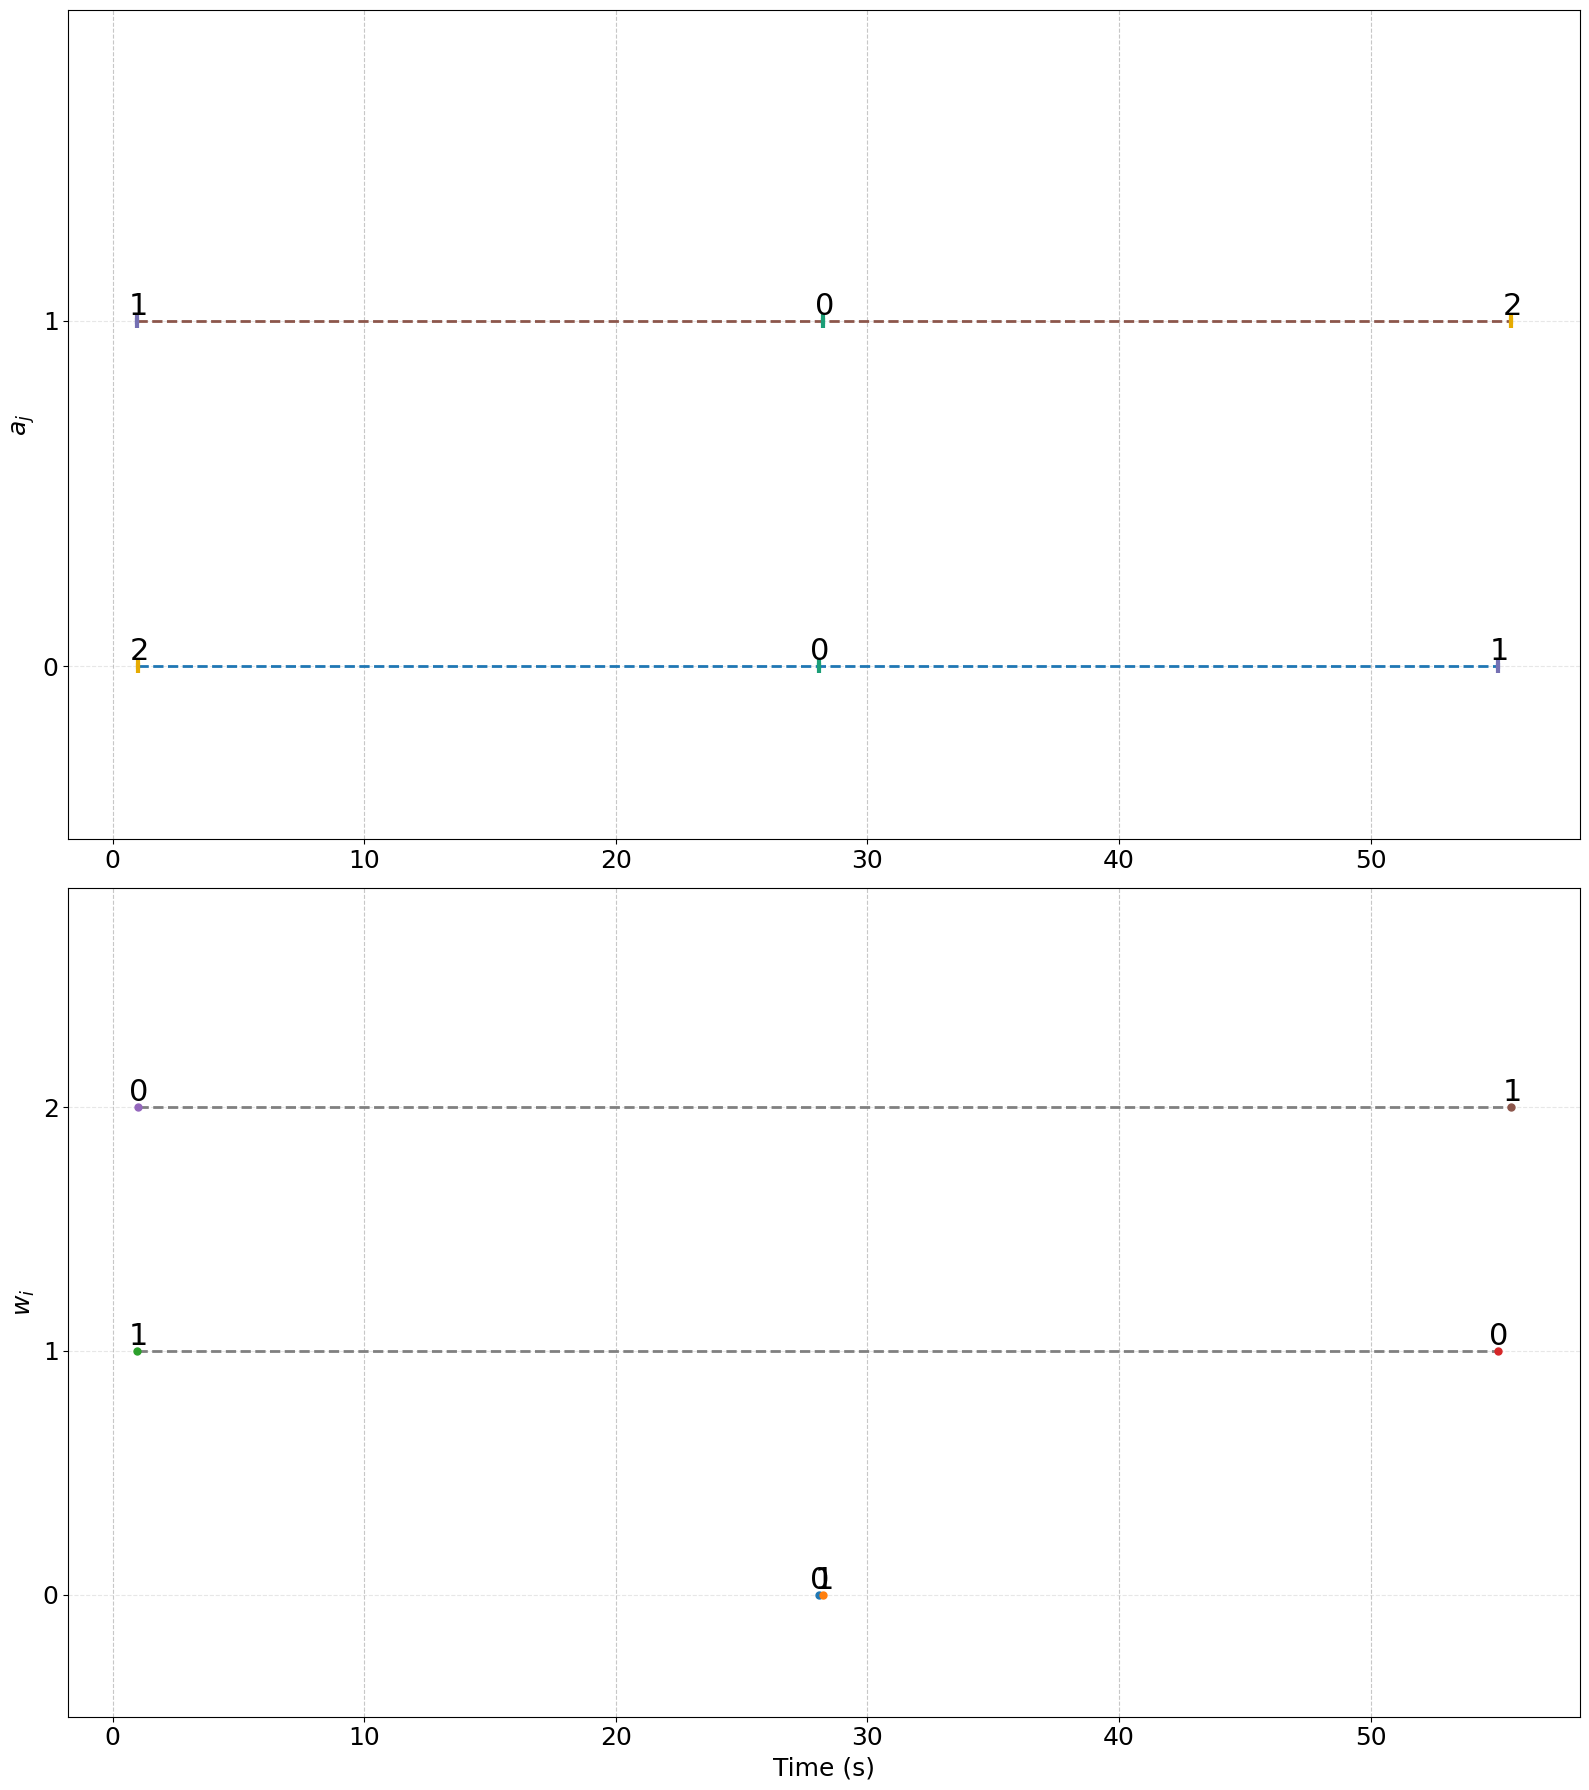

In [14]:
reach_mat = mars.calc_agent_reach_mat_v1(mars.sched_mat, beta_arr[-1])
filter_wp = np.ones(shape=reach_mat.shape)
filter_wp[reach_mat <= 1.0e-10] = 0.0
createEnv.plot_waypoint_agent_schedules(agent_routes, agent_schedules, mars.sched_mat, filter_wp, mars.process_T, agent_colors, figuresize=(16,18))

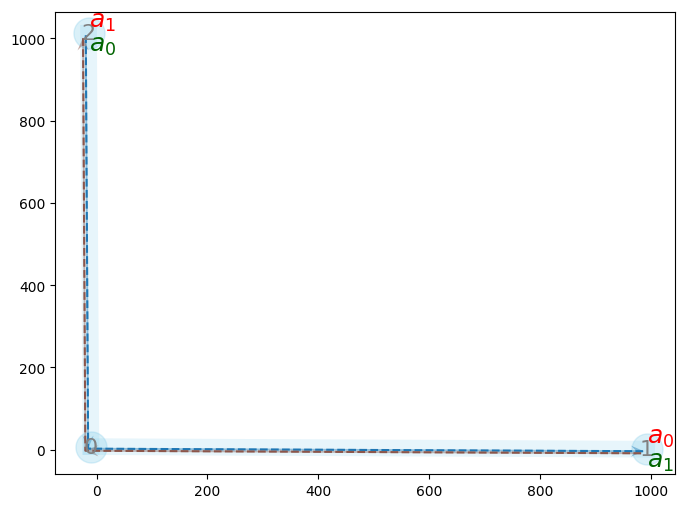

In [17]:
# mars visualization
cmap = get_cmap('tab20')
agent_colors = {a: cmap(i / mars.n_agents) for i, a in enumerate(range(mars.n_agents))}
createEnv.plotNetwork(mars=mars, figuresize=(8,6), routes=agent_routes, agent_colors=agent_colors, showEdgeLength=False)
